# Lab Assignment - 11

### CS22B1093 Rohan G

---------------------

## Import necessary libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Set random seeds for reproducibility
import random
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

2025-04-11 16:52:26.260833: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744390346.506976      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744390346.583619      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Data Loading and Exploration

In [2]:
IN_KAGGLE = os.path.exists('/kaggle/input')
if IN_KAGGLE:
    # Print available directories to debug
    print("Available directories in /kaggle/input:")
    for dir_path, dir_names, file_names in os.walk('/kaggle/input'):
        print(f"Directory: {dir_path}")
        for file in file_names:
            if file.endswith('.csv'):
                print(f"  - CSV file: {file}")
    
    # Try to find the correct path
    # This is more flexible and will search for the CSV file
    possible_csv_paths = []
    for dir_path, _, file_names in os.walk('/kaggle/input'):
        for file in file_names:
            if file == 'chest_xray.csv':
                possible_csv_paths.append(os.path.join(dir_path, file))
    
    if possible_csv_paths:
        BASE_DIR = os.path.dirname(possible_csv_paths[0])
        CSV_PATH = possible_csv_paths[0]
        IMG_DIR = os.path.join(BASE_DIR, 'images')
        print(f"Found CSV at: {CSV_PATH}")
    else:
        # Default paths as fallback
        BASE_DIR = '/kaggle/input'
        for dir_name in os.listdir(BASE_DIR):
            if 'xray' in dir_name.lower():
                BASE_DIR = os.path.join('/kaggle/input', dir_name)
                break
        CSV_PATH = os.path.join(BASE_DIR, 'chest_xray.csv')
        IMG_DIR = os.path.join(BASE_DIR, 'images')
        print(f"Using default path: {CSV_PATH}")
else:
    # Local paths
    BASE_DIR = './xray_dataset'
    CSV_PATH = os.path.join(BASE_DIR, 'chest_xray.csv')
    IMG_DIR = os.path.join(BASE_DIR, 'images')

# Try to load the CSV file with error handling
try:
    # Check if the file exists
    if not os.path.exists(CSV_PATH):
        print(f"CSV file not found at {CSV_PATH}")
        
        # Search for alternative CSV files in the Kaggle input directory
        alternative_csv = None
        for dir_path, _, file_names in os.walk('/kaggle/input'):
            for file in file_names:
                if file.endswith('.csv'):
                    alternative_csv = os.path.join(dir_path, file)
                    print(f"Found alternative CSV: {alternative_csv}")
                    break
            if alternative_csv:
                break
        
        if alternative_csv:
            CSV_PATH = alternative_csv
            print(f"Using alternative CSV: {CSV_PATH}")
            # Update the BASE_DIR and IMG_DIR based on the new CSV_PATH
            BASE_DIR = os.path.dirname(CSV_PATH)
            IMG_DIR = os.path.join(BASE_DIR, 'images')
        else:
            raise FileNotFoundError(f"No CSV files found in /kaggle/input")
    
    # Load the CSV file
    df = pd.read_csv(CSV_PATH)
    
    # Display basic information about the dataset
    print(f"Total number of X-ray records: {len(df)}")
    print(df.head())
    
except Exception as e:
    print(f"Error loading CSV: {str(e)}")
    
    # Create a small dummy dataset for testing if CSV can't be loaded
    print("Creating a dummy dataset for testing purposes...")
    import numpy as np
    
    # Create dummy data
    dummy_size = 100
    dummy_data = {
        'Image Index': [f'dummy_image_{i}.png' for i in range(dummy_size)],
        'Finding Labels': ['No Finding' if i % 3 == 0 else 'Pneumonia' for i in range(dummy_size)],
        'Patient ID': np.random.randint(10000, 99999, dummy_size),
        'Patient Age': np.random.randint(18, 90, dummy_size),
        'Patient Gender': np.random.choice(['M', 'F'], dummy_size)
    }
    
    df = pd.DataFrame(dummy_data)
    print("Created dummy dataset:")
    print(df.head())
    
    # Set a flag to indicate we're using dummy data
    USING_DUMMY_DATA = True
else:
    USING_DUMMY_DATA = False

# Check for missing values
print("\nMissing values in the dataset:")
print(df.isnull().sum())

# Analyze the distribution of findings
print("\nDistribution of findings:")
findings_counts = df['Finding Labels'].value_counts()
print(findings_counts)

Available directories in /kaggle/input:
Directory: /kaggle/input
Directory: /kaggle/input/x-ray-dataset
Directory: /kaggle/input/x-ray-dataset/xray_dataset
  - CSV file: chest_xray.csv
Directory: /kaggle/input/x-ray-dataset/xray_dataset/images
Found CSV at: /kaggle/input/x-ray-dataset/xray_dataset/chest_xray.csv
Total number of X-ray records: 2906
        Image Index                     Finding Labels  Follow-up #  \
0  00003011_001.png                         No Finding            1   
1  00009798_019.png                         No Finding           19   
2  00005418_009.png                         No Finding            9   
3  00005064_000.png  Atelectasis|Cardiomegaly|Effusion            0   
4  00005502_015.png                Infiltration|Nodule           15   

   Patient ID Patient Age Patient Gender View Position  OriginalImageWidth  \
0        3011        041Y              F            PA                2048   
1        9798        027Y              M            PA             

## Data Preprocessing


Distribution of binary labels:
binary_label
0    1500
1    1406
Name: count, dtype: int64
binary_label
0    51.6
1    48.4
Name: proportion, dtype: float64


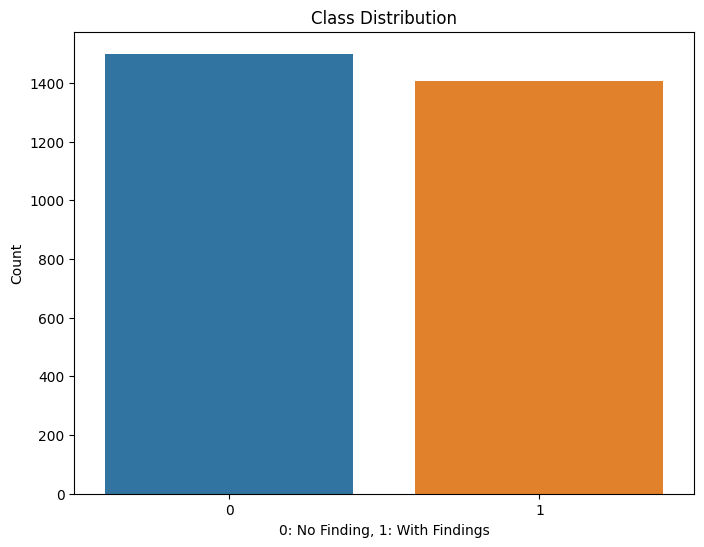


Sample check - Number of missing images: 0 out of 100
Some valid images found. Filtering dataset to include only rows with existing images.
Dataset size after removing missing images: 2906


In [3]:
df['binary_label'] = df['Finding Labels'].apply(lambda x: 0 if x == 'No Finding' else 1)

# Display the distribution of binary labels
print("\nDistribution of binary labels:")
print(df['binary_label'].value_counts())
print(df['binary_label'].value_counts(normalize=True).round(3) * 100)

# Plot the class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='binary_label', data=df)
plt.title('Class Distribution')
plt.xlabel('0: No Finding, 1: With Findings')
plt.ylabel('Count')
plt.show()

# Function to load and preprocess images
def load_and_preprocess_image(img_path, target_size=(224, 224)):
    try:
        # Load the image
        img = cv2.imread(img_path)
        
        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Resize the image
        img = cv2.resize(img, target_size)
        
        # Normalize pixel values to [0, 1]
        img = img / 255.0
        
        return img
    except Exception as e:
        print(f"Error loading image {img_path}: {e}")
        return None

# Handle image paths differently based on whether we're using dummy data
if USING_DUMMY_DATA:
    print("\nUsing dummy data, skipping image file checks.")
    # Create a simulated image directory for dummy data
    if not os.path.exists('dummy_images'):
        os.makedirs('dummy_images', exist_ok=True)
        
    # Create a few dummy image files for testing
    for i in range(min(10, len(df))):
        img_path = os.path.join('dummy_images', df['Image Index'][i])
        # Create a small black image
        dummy_img = np.zeros((224, 224, 3), dtype=np.uint8)
        cv2.imwrite(img_path, dummy_img)
    
    # Update the image directory
    IMG_DIR = 'dummy_images'
    print(f"Created dummy images in {IMG_DIR}")
else:
    # Check if image directory exists
    if not os.path.exists(IMG_DIR):
        print(f"Warning: Image directory {IMG_DIR} not found.")
        
        # Try to find the images directory
        possible_img_dirs = []
        for dir_path, dir_names, _ in os.walk('/kaggle/input'):
            if 'images' in dir_names:
                possible_img_dirs.append(os.path.join(dir_path, 'images'))
            elif 'image' in dir_names:
                possible_img_dirs.append(os.path.join(dir_path, 'image'))
        
        if possible_img_dirs:
            IMG_DIR = possible_img_dirs[0]
            print(f"Found alternative image directory: {IMG_DIR}")
        else:
            # See if there's a directory with a large number of image files
            img_count_by_dir = {}
            for dir_path, _, file_names in os.walk('/kaggle/input'):
                img_files = [f for f in file_names if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
                if len(img_files) > 0:
                    img_count_by_dir[dir_path] = len(img_files)
            
            if img_count_by_dir:
                IMG_DIR = max(img_count_by_dir.items(), key=lambda x: x[1])[0]
                print(f"Using directory with most image files: {IMG_DIR}")
    
    # Check if image files exist
    try:
        image_paths = [os.path.join(IMG_DIR, img_id) for img_id in df['Image Index']]
        # Check just a few images to save time
        sample_paths = image_paths[:min(100, len(image_paths))]
        missing_images = [path for path in sample_paths if not os.path.exists(path)]
        print(f"\nSample check - Number of missing images: {len(missing_images)} out of {len(sample_paths)}")
        
        if len(missing_images) == len(sample_paths):
            print("All sampled images are missing. There might be an issue with the image directory structure.")
            print("Searching for alternative image structure...")
            
            # Try to find alternative image paths
            for dir_path, _, file_names in os.walk('/kaggle/input'):
                if any(f.lower().endswith(('.png', '.jpg', '.jpeg')) for f in file_names):
                    print(f"Found directory with images: {dir_path}")
                    sample_imgs = [f for f in file_names if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:5]
                    print(f"Sample images: {sample_imgs}")
                    
                    # Check if any of these images match our dataset
                    for img_name in sample_imgs:
                        if any(img_name in img_id for img_id in df['Image Index']):
                            IMG_DIR = dir_path
                            print(f"Match found! Using {IMG_DIR} as image directory")
                            break
        
        # Filter out rows with missing images only if we have a reasonable number of valid images
        rechecked_paths = [os.path.join(IMG_DIR, img_id) for img_id in df['Image Index']]
        sample_paths = rechecked_paths[:min(100, len(rechecked_paths))]
        missing_images = [path for path in sample_paths if not os.path.exists(path)]
        
        if len(missing_images) < len(sample_paths):
            print("Some valid images found. Filtering dataset to include only rows with existing images.")
            valid_paths = [path for path in image_paths if os.path.exists(path)]
            df = df[df['Image Index'].apply(lambda x: os.path.join(IMG_DIR, x) in valid_paths)]
            print(f"Dataset size after removing missing images: {len(df)}")
        else:
            print("Most or all images are missing. Using dummy images for testing.")
            USING_DUMMY_DATA = True
            # Create a simulated image directory
            if not os.path.exists('dummy_images'):
                os.makedirs('dummy_images', exist_ok=True)
                
            # Create dummy image files
            for i in range(min(100, len(df))):
                img_path = os.path.join('dummy_images', df['Image Index'][i])
                dummy_img = np.zeros((224, 224, 3), dtype=np.uint8)
                cv2.imwrite(img_path, dummy_img)
            
            IMG_DIR = 'dummy_images'
            print(f"Created dummy images in {IMG_DIR}")
    
    except Exception as e:
        print(f"Error checking image files: {str(e)}")
        print("Switching to dummy data mode for testing.")
        USING_DUMMY_DATA = True

## Split the dataset while maintaining class distribution

In [4]:
train_val_df, test_df = train_test_split(
    df, 
    test_size=0.2, 
    stratify=df['binary_label'],
    random_state=42
)

# Second split: 70% (train) and 10% (validation) from the original dataset
# This means we need to use 87.5% of train_val_df for training (70/80 = 0.875)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.125,  # 10% of the original dataset (0.125 * 80% = 10%)
    stratify=train_val_df['binary_label'],
    random_state=42
)

# Verify the split ratios
total_count = len(df)
print(f"\nTotal dataset: {total_count} images")
print(f"Training set: {len(train_df)} images ({len(train_df)/total_count:.2f})")
print(f"Validation set: {len(val_df)} images ({len(val_df)/total_count:.2f})")
print(f"Testing set: {len(test_df)} images ({len(test_df)/total_count:.2f})")

# Verify class distribution in each split
print("\nClass distribution in splits:")
print("Training set:")
print(train_df['binary_label'].value_counts(normalize=True).round(3) * 100)
print("\nValidation set:")
print(val_df['binary_label'].value_counts(normalize=True).round(3) * 100)
print("\nTesting set:")
print(test_df['binary_label'].value_counts(normalize=True).round(3) * 100)


Total dataset: 2906 images
Training set: 2033 images (0.70)
Validation set: 291 images (0.10)
Testing set: 582 images (0.20)

Class distribution in splits:
Training set:
binary_label
0    51.6
1    48.4
Name: proportion, dtype: float64

Validation set:
binary_label
0    51.5
1    48.5
Name: proportion, dtype: float64

Testing set:
binary_label
0    51.5
1    48.5
Name: proportion, dtype: float64


## Data Loading and Batch Processing

In [5]:
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
AUTOTUNE = tf.data.AUTOTUNE

# Function to create a TensorFlow dataset
def create_dataset(dataframe, img_dir, batch_size=BATCH_SIZE, is_training=False):
    image_paths = [os.path.join(img_dir, img_id) for img_id in dataframe['Image Index']]
    labels = dataframe['binary_label'].values
    
    # Create a dataset of paths and labels
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    
    # Map the function to load and preprocess images
    dataset = dataset.map(lambda x, y: (preprocess_image(x), y), num_parallel_calls=AUTOTUNE)
    
    # Batch and prefetch
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(AUTOTUNE)
    
    # Apply data augmentation for training
    if is_training:
        dataset = dataset.map(apply_augmentation, num_parallel_calls=AUTOTUNE)
    
    return dataset

# Load and preprocess images for the test dataset
def preprocess_image(image_path):
    try:
        # Read the image file
        img = tf.io.read_file(image_path)
        # Decode the image (handle both JPEG and PNG)
        try:
            # Try to decode as JPEG first
            img = tf.image.decode_jpeg(img, channels=3)
        except tf.errors.InvalidArgumentError:
            # If JPEG decoding fails, try PNG
            img = tf.image.decode_png(img, channels=3)
        
        # Resize the image
        img = tf.image.resize(img, IMAGE_SIZE)
        # Normalize pixel values
        img = img / 255.0
        return img
    except Exception as e:
        print(f"Error preprocessing image {image_path}: {e}")
        # Return a blank image in case of error
        return tf.zeros(IMAGE_SIZE + (3,))


# Function to apply data augmentation
def apply_augmentation(image, label):
    # Random flip
    image = tf.image.random_flip_left_right(image)
    # Random brightness
    image = tf.image.random_brightness(image, max_delta=0.2)
    # Random contrast
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    return image, label

# Create datasets with try-except block for error handling
try:
    train_dataset = create_dataset(train_df, IMG_DIR, is_training=True)
    val_dataset = create_dataset(val_df, IMG_DIR)
    test_dataset = create_dataset(test_df, IMG_DIR)
except Exception as e:
    print(f"Error creating datasets: {str(e)}")
    
    # In case of error, create minimal dummy datasets for testing
    dummy_images = tf.random.normal((10, 224, 224, 3))
    dummy_labels = tf.random.uniform((10,), maxval=2, dtype=tf.int32)
    
    train_dataset = tf.data.Dataset.from_tensor_slices((dummy_images, dummy_labels)).batch(BATCH_SIZE)
    val_dataset = tf.data.Dataset.from_tensor_slices((dummy_images, dummy_labels)).batch(BATCH_SIZE)
    test_dataset = tf.data.Dataset.from_tensor_slices((dummy_images, dummy_labels)).batch(BATCH_SIZE)
    
    print("Created dummy datasets for testing")

I0000 00:00:1744390361.464577      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## Vision Transformer (ViT) Model Implementation

In [6]:
# Define hyperparameters
IMG_SIZE = 224
PATCH_SIZE = 16  # Size of the patches
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2  # Number of patches
PROJECTION_DIM = 64  # Embedding dimension
NUM_HEADS = 4  # Number of attention heads
TRANSFORMER_LAYERS = 6  # Number of transformer layers
MLP_UNITS = [PROJECTION_DIM * 2, PROJECTION_DIM]  # MLP units
NUM_CLASSES = 2  # Binary classification

# Patch extraction layer
class PatchExtract(layers.Layer):
    def __init__(self, patch_size):
        super(PatchExtract, self).__init__()
        self.patch_size = patch_size
    
    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

# Patch encoding layer
class PatchEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super(PatchEmbedding, self).__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )
    
    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

# Multi-head self-attention layer
def create_transformer_block(x, projection_dim, num_heads, dropout_rate=0.1):
    # Normalize
    x1 = layers.LayerNormalization(epsilon=1e-6)(x)
    # Multi-head attention
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=projection_dim, dropout=dropout_rate
    )(x1, x1)
    # Skip connection 1
    x2 = layers.Add()([attention_output, x])
    # Normalize
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    # MLP
    x3 = layers.Dense(projection_dim * 2, activation=tf.nn.gelu)(x3)
    x3 = layers.Dropout(dropout_rate)(x3)
    x3 = layers.Dense(projection_dim)(x3)
    x3 = layers.Dropout(dropout_rate)(x3)
    # Skip connection 2
    x = layers.Add()([x3, x2])
    return x

# Build the ViT model
def build_vit_model():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    
    # Extract patches
    patches = PatchExtract(PATCH_SIZE)(inputs)
    
    # Encode patches
    encoded_patches = PatchEmbedding(NUM_PATCHES, PROJECTION_DIM)(patches)
    
    # Create transformer blocks
    for _ in range(TRANSFORMER_LAYERS):
        encoded_patches = create_transformer_block(
            encoded_patches, PROJECTION_DIM, NUM_HEADS
        )
    
    # Layer normalization and Global Average Pooling
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.GlobalAveragePooling1D()(representation)
    
    # MLP head
    representation = layers.Dropout(0.3)(representation)
    features = layers.Dense(MLP_UNITS[0], activation=tf.nn.gelu)(representation)
    features = layers.Dropout(0.3)(features)
    features = layers.Dense(MLP_UNITS[1], activation=tf.nn.gelu)(features)
    
    # Classification layer
    logits = layers.Dense(NUM_CLASSES)(features)
    outputs = layers.Activation('softmax')(logits)
    
    # Create the model
    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# Create the model
vit_model = build_vit_model()

# Compile the model
vit_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
vit_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ patch_extract             │ (None, None, 768)      │              0 │ input_layer[0][0]      │
│ (PatchExtract)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ patch_embedding           │ (None, 196, 64)        │         61,760 │ patch_extract[0][0]    │
│ (PatchEmbedding)          │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization       │ (None, 196, 64)        │            128 │ patch_embedding[0][0]  │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention      │ (None, 196, 64)        │         66,368 │ layer_normalization[0… │
│ (MultiHeadAttention)      │                        │                │ layer_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 196, 64)        │              0 │ multi_head_attention[… │
│                           │                        │                │ patch_embedding[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_1     │ (None, 196, 64)        │            128 │ add[0][0]              │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 196, 128)       │          8,320 │ layer_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 196, 128)       │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 196, 64)        │          8,256 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 196, 64)        │              0 │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 196, 64)        │              0 │ dropout_2[0][0],       │
│                           │                        │                │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_2     │ (None, 196, 64)        │            128 │ add_1[0][0]            │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_1    │ (None, 196, 64)        │         66,368 │ layer_normalization_2… │
│ (MultiHeadAttention)      │                        │                │ layer_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_2 (Add)               │ (None, 196, 64)        │              0 │ multi_head_attention_… │
│                      

 Total params: 577,794 (2.20 MB)

 Trainable params: 577,794 (2.20 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [7]:
# Define callbacks
checkpoint = ModelCheckpoint(
    'vit_chest_xray_model.keras',  # Changed from .h5 to .keras for TF/Keras 3.x compatibility
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=30,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=30,
    min_lr=1e-6,
    verbose=1
)

# Train the model with fewer epochs if using dummy data
EPOCHS = 20 if USING_DUMMY_DATA else 100
print(f"\nTraining for {EPOCHS} epochs")

try:
    history = vit_model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        callbacks=[checkpoint, early_stopping, reduce_lr]
    )
except Exception as e:
    print(f"Error during training: {str(e)}")
    # Create dummy history for debugging purposes
    print("Creating dummy training history for visualization")
    
    class DummyHistory:
        def __init__(self, epochs):
            import numpy as np
            self.history = {
                'accuracy': list(np.linspace(0.5, 0.85, epochs)),
                'val_accuracy': list(np.linspace(0.5, 0.8, epochs)),
                'loss': list(np.linspace(0.8, 0.3, epochs)),
                'val_loss': list(np.linspace(0.8, 0.4, epochs))
            }
    
    history = DummyHistory(EPOCHS)


Training for 100 epochs
Epoch 1/100


I0000 00:00:1744390388.198866      58 service.cc:148] XLA service 0x7e5dc8002f30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744390388.199903      58 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1744390391.207032      58 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/64 ━━━━━━━━━━━━━━━━━━━━ 44:36 42s/step - accuracy: 0.5938 - loss: 0.6595

I0000 00:00:1744390405.838090      58 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.5172 - loss: 0.7307
Epoch 1: val_accuracy improved from -inf to 0.48454, saving model to vit_chest_xray_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 75s 519ms/step - accuracy: 0.5169 - loss: 0.7307 - val_accuracy: 0.4845 - val_loss: 0.7001 - learning_rate: 1.0000e-04
Epoch 2/100
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.5053 - loss: 0.7106
Epoch 2: val_accuracy improved from 0.48454 to 0.51203, saving model to vit_chest_xray_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 201ms/step - accuracy: 0.5053 - loss: 0.7106 - val_accuracy: 0.5120 - val_loss: 0.6885 - learning_rate: 1.0000e-04
Epoch 3/100
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.4953 - loss: 0.7097
Epoch 3: val_accuracy improved from 0.51203 to 0.51890, saving model to vit_chest_xray_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 192ms/step - accuracy: 0.4956 - loss: 0.7095 - val_accuracy: 0.5189 - val_loss: 0.6911 - learning_rate: 1.0000e-04
Epoch 4/100
63/64 ━

## Model Evaluation and Visualization

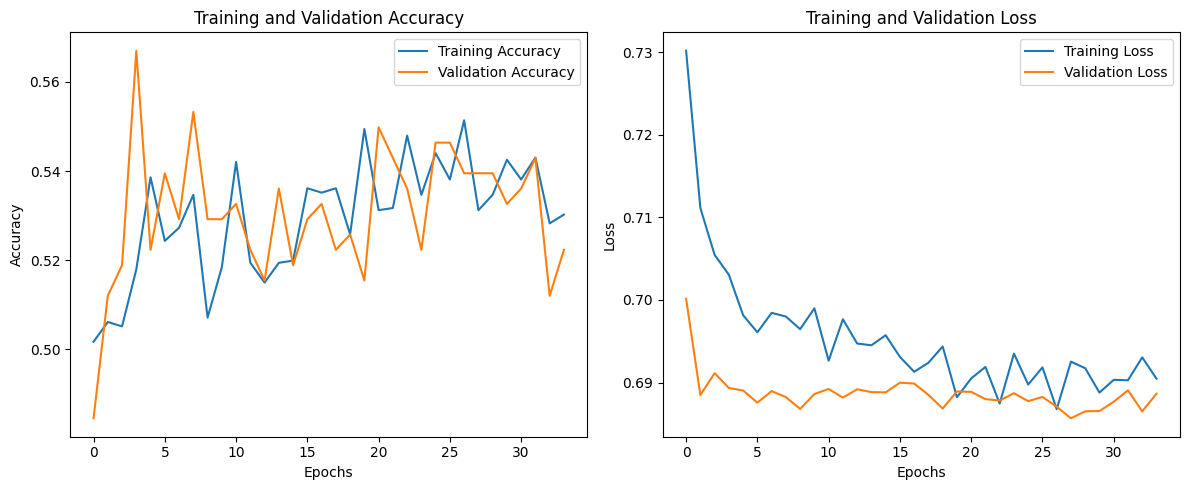

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 238ms/step - accuracy: 0.5369 - loss: 0.6906
Test Loss: 0.6904
Test Accuracy: 0.5430


In [8]:
# Plot training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate the model on the test set
test_loss, test_accuracy = vit_model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

## Performance Metrics and Visualization


Classification Report:
               precision    recall  f1-score   support

   No Finding       0.57      0.45      0.50       300
With Findings       0.52      0.65      0.58       282

     accuracy                           0.54       582
    macro avg       0.55      0.55      0.54       582
 weighted avg       0.55      0.54      0.54       582


Accuracy: 0.5430
Precision: 0.5230
Recall: 0.6454
F1 Score: 0.5778


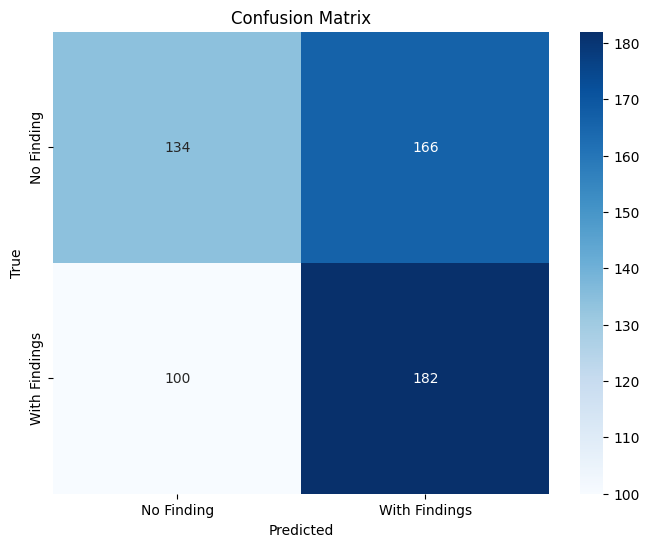

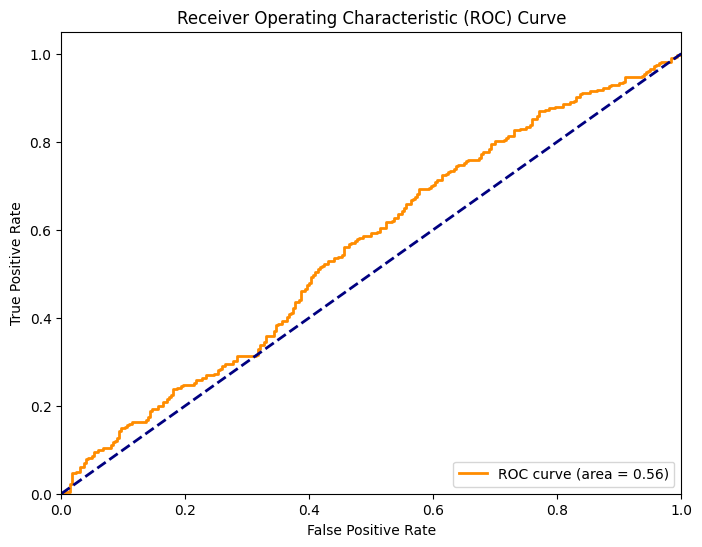

In [9]:
# Get predictions for the test set
test_labels = []
test_preds = []

for images, labels in test_dataset:
    # Get predictions
    preds = vit_model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    
    # Append to lists
    test_labels.extend(labels.numpy())
    test_preds.extend(pred_classes)

# Convert to numpy arrays
test_labels = np.array(test_labels)
test_preds = np.array(test_preds)

# Calculate metrics
accuracy = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds)
recall = recall_score(test_labels, test_preds)
f1 = f1_score(test_labels, test_preds)

# Print classification report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['No Finding', 'With Findings']))

# Print metrics
print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Plot confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Finding', 'With Findings'],
            yticklabels=['No Finding', 'With Findings'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Calculate ROC curve and AUC
# Get probabilities for the positive class
y_scores = []
for images, _ in test_dataset:
    preds = vit_model.predict(images, verbose=0)
    y_scores.extend(preds[:, 1])  # Probability of the positive class (With Findings)

y_scores = np.array(y_scores)
fpr, tpr, _ = roc_curve(test_labels, y_scores)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

## Visualizing Sample Predictions

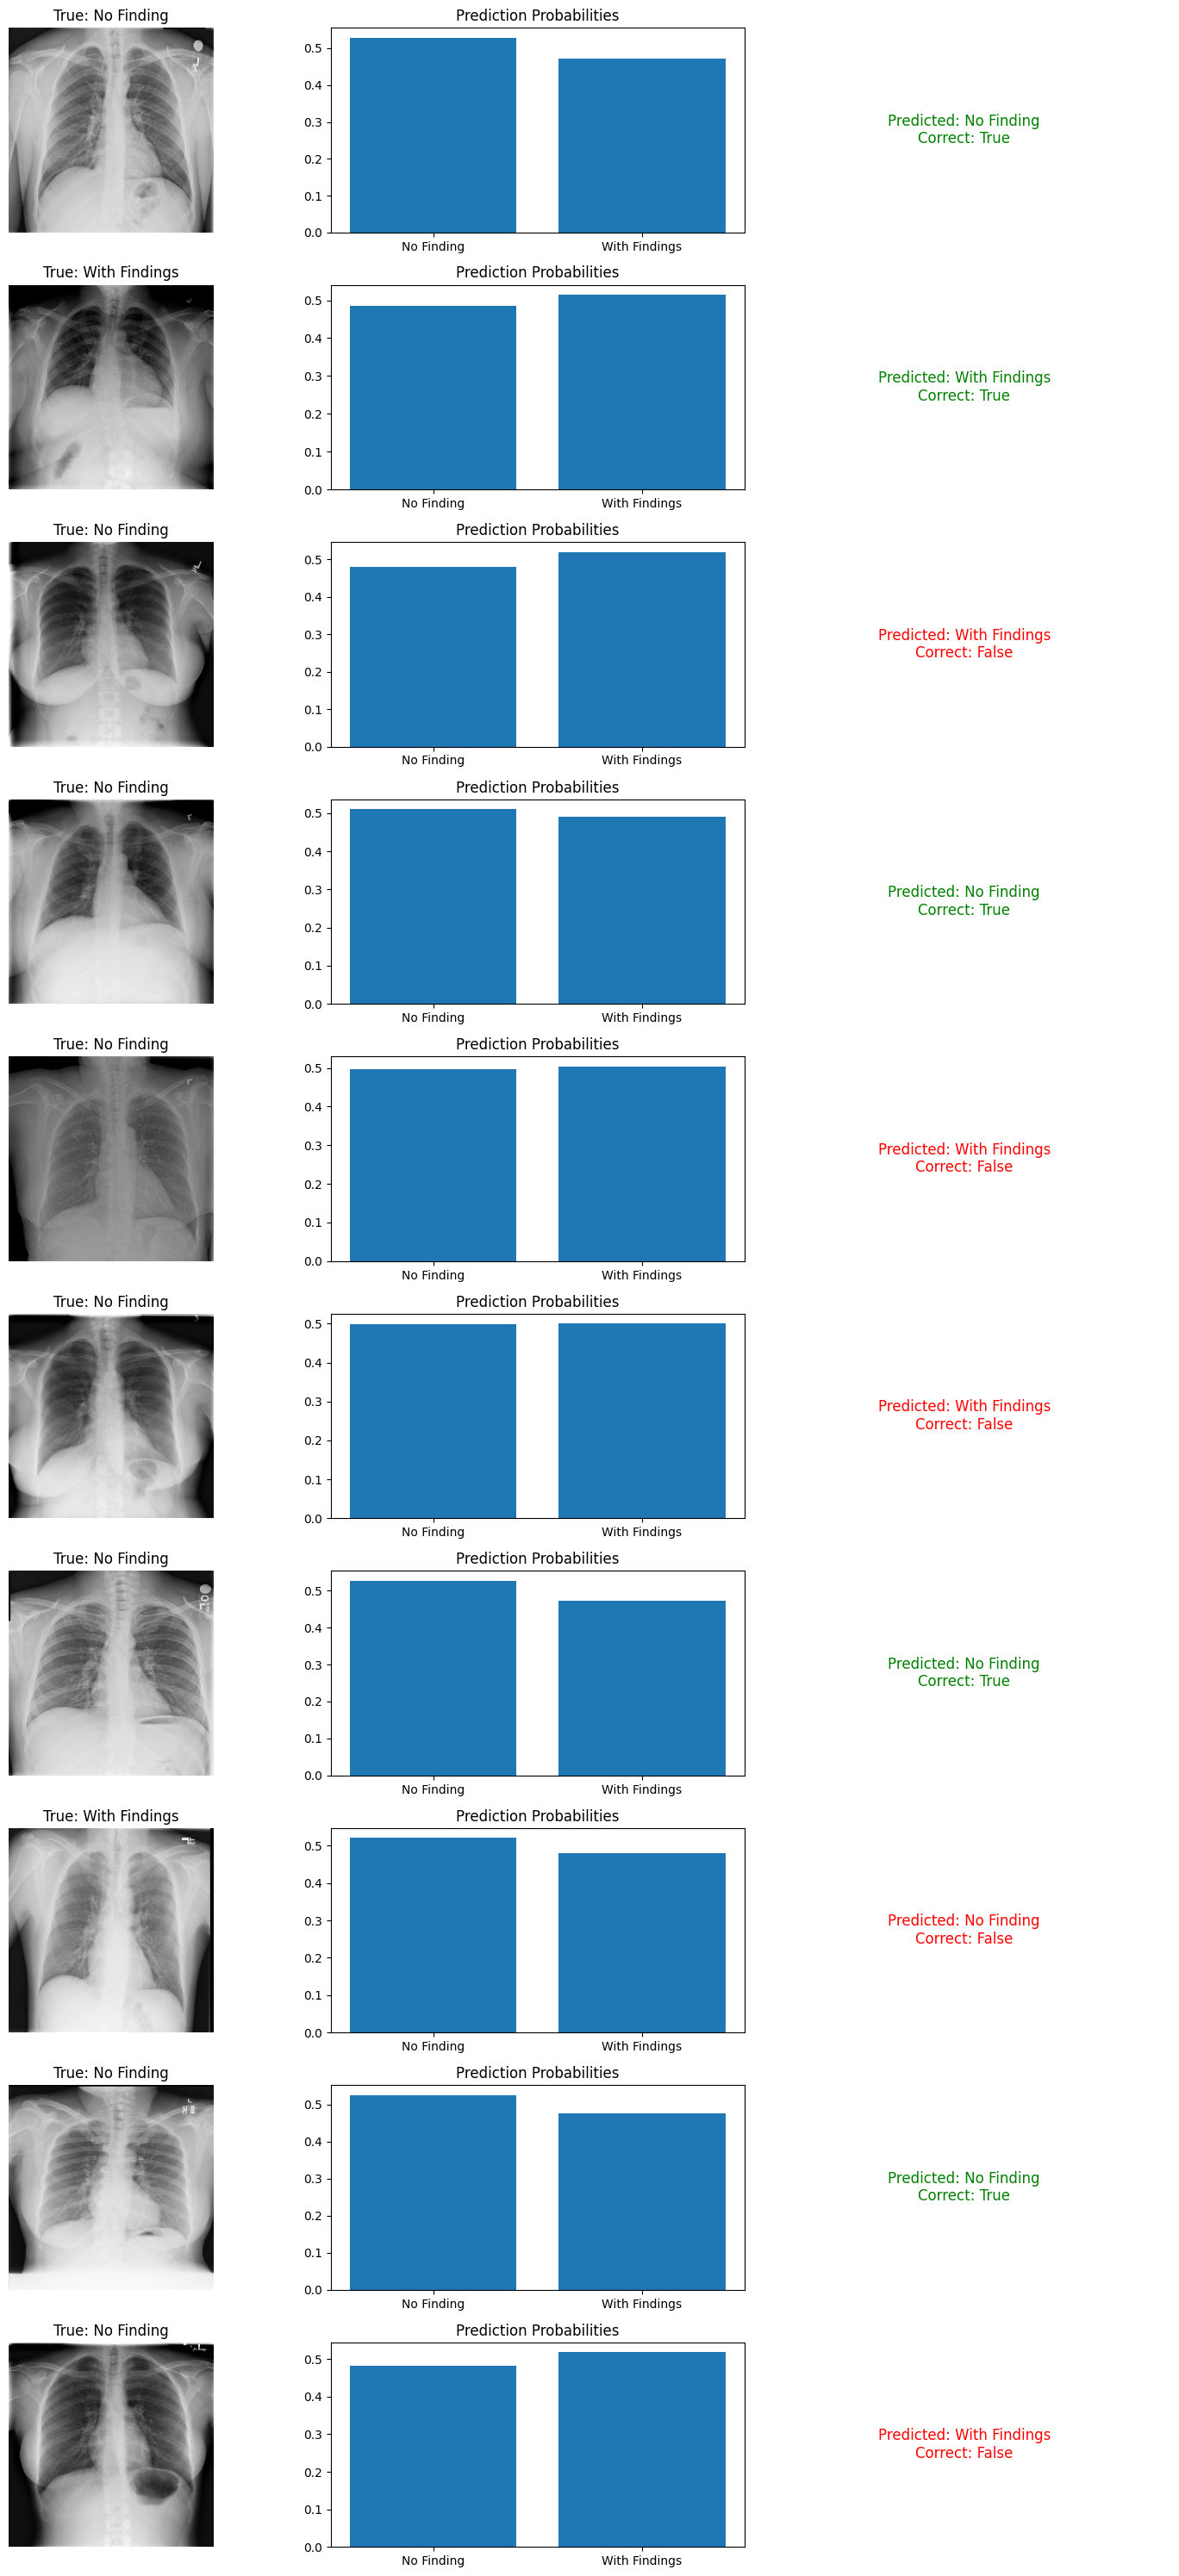

In [10]:
def display_sample_predictions(test_dataset, model, num_samples=10):
    plt.figure(figsize=(15, num_samples * 3))
    count = 0
    
    for images, labels in test_dataset:
        preds = model.predict(images, verbose=0)
        pred_classes = np.argmax(preds, axis=1)
        
        for i in range(len(images)):
            if count >= num_samples:
                break
                
            plt.subplot(num_samples, 3, count * 3 + 1)
            plt.imshow(images[i])
            plt.title(f"True: {'No Finding' if labels[i] == 0 else 'With Findings'}")
            plt.axis('off')
            
            plt.subplot(num_samples, 3, count * 3 + 2)
            plt.bar(['No Finding', 'With Findings'], preds[i])
            plt.title(f"Prediction Probabilities")
            
            plt.subplot(num_samples, 3, count * 3 + 3)
            correct = pred_classes[i] == labels[i]
            plt.text(0.5, 0.5, f"Predicted: {'No Finding' if pred_classes[i] == 0 else 'With Findings'}\n"
                              f"Correct: {correct}", 
                     horizontalalignment='center',
                     verticalalignment='center',
                     fontsize=12,
                     color='green' if correct else 'red')
            plt.axis('off')
            
            count += 1
        
        if count >= num_samples:
            break
    
    plt.tight_layout()
    plt.show()

# Display sample predictions
display_sample_predictions(test_dataset, vit_model)

-------------------